# Latent Dynamics Estimation on a Synthetic Generator (Tasks 3.1–3.4)

In [54]:
import numpy as np
import pandas as pd
import scipy as sp
import matplotlib.pyplot as plt
from scipy.spatial.distance import pdist, squareform
from scipy.spatial import procrustes
from scipy.linalg import orthogonal_procrustes, subspace_angles

LATENT_SEED, FEATURE_SEED, NOISE_SEED = 0, 1, 2

## 2.1 — Task 3.1: synthetic OU generator on $S^2$

In [55]:
def simulate_ou_on_sphere(mu=np.array([0., 0., 1.]), kappa=0.5, sigma=0.2,
                          dt=0.01, T=100, d=2, rand_seed=0):
    rng = np.random.default_rng(rand_seed)                      
    N = int(T/dt) + 1
    Y = np.zeros((N, d))
    stat_sd = sigma/np.sqrt(2*kappa)
    Y[0] = rng.normal(0.0, stat_sd, size=d)                     
    a      = np.exp(-kappa*dt)                                  
    ou_std = np.sqrt(sigma**2/(2*kappa)*(1 - np.exp(-2*kappa*dt)))  
    for t in range(1, N):
        Y[t] = a*Y[t-1] + ou_std*rng.normal(0.0, 1.0, size=d)  

    mu = np.asarray(mu, float); mu /= np.linalg.norm(mu)
    ref = np.array([0., 0., 1.]) if abs(mu[2]) < 0.9 else np.array([0., 1., 0.])
    u1 = np.cross(ref, mu); u1 /= np.linalg.norm(u1)
    u2 = np.cross(mu, u1)                                       
    Yn = np.linalg.norm(Y, axis=1)
    sinc = np.divide(np.sin(Yn), Yn, where=Yn != 0, out=np.ones_like(Yn))
    tangent = Y[:, 0][:, None]*u1 + Y[:, 1][:, None]*u2
    X = np.cos(Yn)[:, None]*mu + sinc[:, None]*tangent

    assert Yn.max() < np.pi, "exp_mu not injective: ||Y|| reached pi"
    assert np.allclose(np.linalg.norm(X, axis=1), 1.0), "X left S^2"
    return X, Y

X, Y = simulate_ou_on_sphere(rand_seed=LATENT_SEED)
print("max ||Y_t||        =", np.linalg.norm(Y, axis=1).max())
print("max | ||X_t|| - 1 | =", np.abs(np.linalg.norm(X, axis=1) - 1).max())

max ||Y_t||        = 0.6872862044796194
max | ||X_t|| - 1 | = 1.1102230246251565e-16


### Plot the trajectory on the sphere

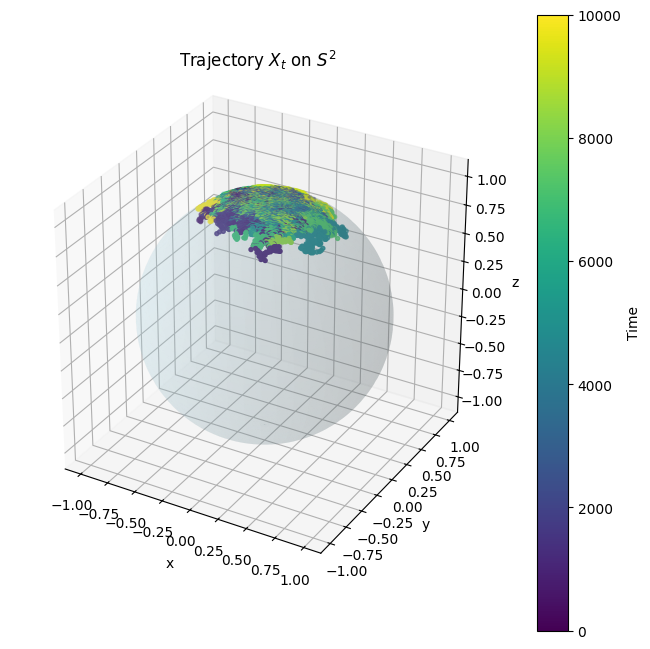

In [56]:
fig = plt.figure(figsize=(8, 8)); ax = fig.add_subplot(111, projection='3d')
u = np.linspace(0, 2*np.pi, 100); v = np.linspace(0, np.pi, 100)
ax.plot_surface(np.outer(np.cos(u), np.sin(v)), np.outer(np.sin(u), np.sin(v)),
                np.outer(np.ones_like(u), np.cos(v)), alpha=0.15, color='lightblue', linewidth=0)
sc = ax.scatter(X[:, 0], X[:, 1], X[:, 2], c=np.arange(len(X)), cmap='viridis', s=8)
fig.colorbar(sc, ax=ax, label='Time'); ax.set_box_aspect([1, 1, 1])
ax.set_xlabel('x'); ax.set_ylabel('y'); ax.set_zlabel('z')
ax.set_title(r'Trajectory $X_t$ on $S^2$'); plt.show()

### Data splits

**`dt_eff` is defined here, once.** After thinning by `gap`, the effective sampling interval
is $\Delta t_{\rm eff} = \text{gap}\cdot\Delta t = 0.1$. Every estimator downstream MUST use
`dt_eff`, not `dt`. Using `dt=0.01` on `gap`-thinned data scales $\hat\kappa$ by a factor of 10 —
this was the latent trap in the original Task 3.4 cell.

**Burn-in retained** for the geometry split even though previous fix makes the chain stationary at $t=0$;

In [57]:
burnin, gap = 500, 10
dt = 0.01
dt_eff = gap*dt                                   

X_geom, Y_geom = X[burnin::gap], Y[burnin::gap]   
print("n_geom =", X_geom.shape[0], " dt_eff =", dt_eff)

n_geom = 951  dt_eff = 0.1


## 2.2 — Task 3.2: noisy high-dimensional observation

In [58]:
def draw_feature_map(D=100, seed=FEATURE_SEED, d=3):
    rng = np.random.default_rng(seed)
    W = rng.standard_normal((D, d))               
    b = rng.uniform(0, 2*np.pi, size=D)
    return W, b

def embed_with_noise(X, W, b, D, eta, sigma_eta):
    G = np.cos(X @ W[:D].T + b[:D])               
    Z = G + sigma_eta*eta[:, :D]                  
    return {"Zobs": Z, "Gclean": G, "D": D, "sigma_eta": sigma_eta}

W, b = draw_feature_map(100, FEATURE_SEED)
eta  = np.random.default_rng(NOISE_SEED).standard_normal((X_geom.shape[0], 100))

sigma_etas, Ds = [0.0, 0.05, 0.1, 0.2], [50, 100]

### Observed coordinates look nothing like OU

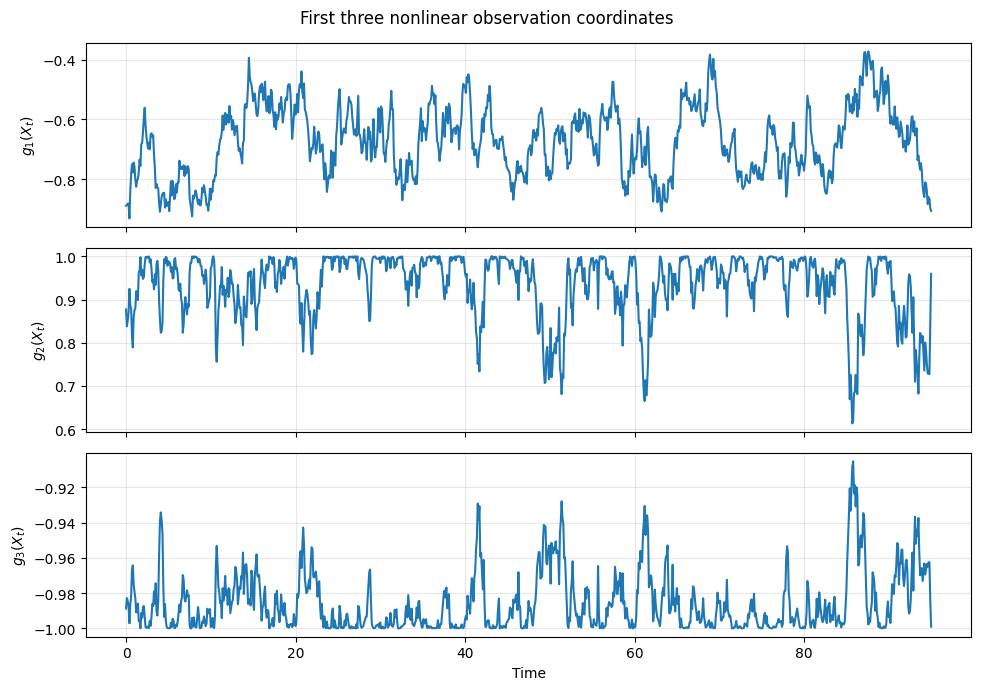

In [59]:
G = embed_with_noise(X_geom, W, b, 50, eta, 0.0)["Gclean"]
t = np.arange(len(G))*dt_eff
fig, axes = plt.subplots(3, 1, figsize=(10, 7), sharex=True)
for j in range(3):
    axes[j].plot(t, G[:, j]); axes[j].set_ylabel(rf"$g_{{{j+1}}}(X_t)$"); axes[j].grid(alpha=.3)
axes[-1].set_xlabel("Time"); fig.suptitle("First three nonlinear observation coordinates")
plt.tight_layout(); plt.show()

## 2.3 — Task 3.3: bandwidth, diffusion map, latent recovery

### The Coifman–Lafon slope: why it sits below 1

**Diagnosis** The issue with it sitting below 1 is not due to noise but rather two separate mechanisms act, and noise is neither the dominant one nor in the blamed direction:

1. **Finite-sample bias (downward).** $T(\varepsilon)\sim C\varepsilon^{k/2}$ is asymptotic; at
   $n\approx 951$ the slope approaches $1$ from below (uniform full sphere gives $\approx 0.99$ only
   by $n=4000$).
2. **OU concentration (downward, dominant).** With $\sigma/\sqrt{2\kappa}=0.2$ the path stays in a
   geodesic cap covering $\approx 11\%$ of $S^2$. A small cap is locally flat (still $k=2$) but the
   clean scaling window is compressed, pinning the empirical slope near $0.94$ regardless of $n$.
3. **Noise (UPWARD).** Isotropic noise inflates every squared distance by $\approx 2D\sigma_\eta^2$,
   raising the nearest-neighbour scale and pushing the slope ABOVE 1 (to $\sim 3$), not below.

So: under-estimation from concentration + finite $n$ in the clean case; over-estimation from the noise
floor in the dirty case. $\varepsilon^\star$ chosen at the midpoint of the cleanest linear stretch
remains a sound bandwidth.

**Bandwidth selected per cloud**
$\varepsilon^\star$ calibrated to the $D=50$ distance code.

recovered k/2 estimate (max local slope) = 0.933
eps_star (D=50, clean)                   = 0.0971


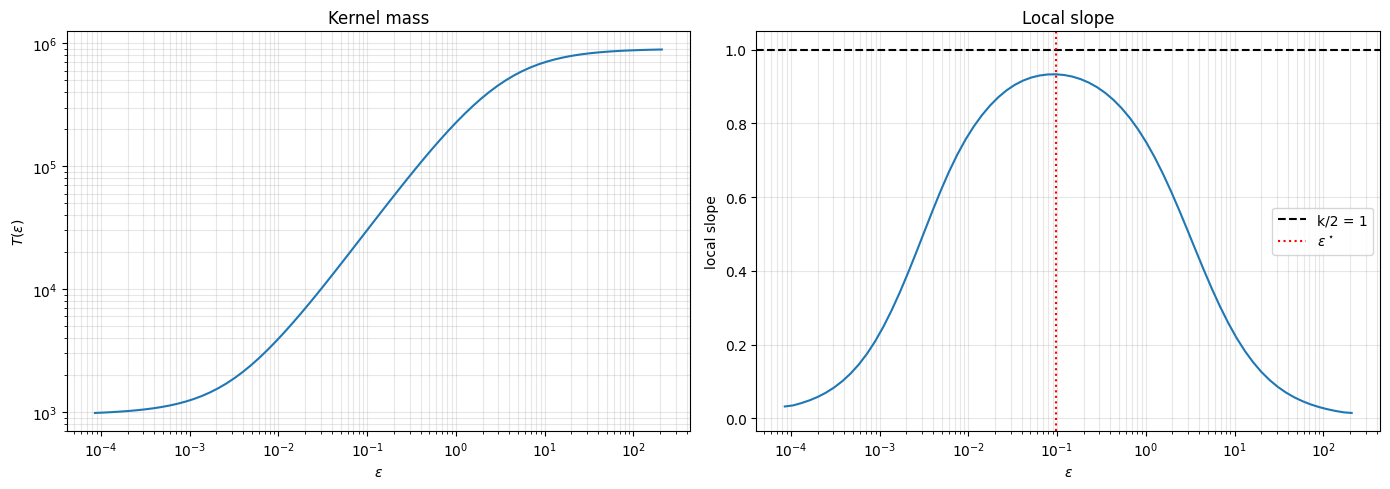

In [60]:
def kernel_mass_slope(data, npts=70, lo=-1.5, hi=2.0):
    Dsq = squareform(pdist(data)**2)
    Dnd = Dsq.copy(); np.fill_diagonal(Dnd, np.inf)
    d_min = np.median(Dnd.min(1)); d_med = np.median(Dsq[np.triu_indices_from(Dsq, 1)])
    grid = np.logspace(np.log10(d_min)+lo, np.log10(d_med)+hi, npts)
    upper = Dsq[np.triu_indices_from(Dsq, 1)]
    T = np.array([2*np.exp(-upper/e).sum() + Dsq.shape[0] for e in grid])
    slope = np.gradient(np.log(T), np.log(grid))
    return grid, T, slope

def select_epsilon(data):
    grid, T, slope = kernel_mass_slope(data)
    i = int(np.argmax(slope))
    lo = max(i-5, 0); hi = min(i+5, len(grid)-1)
    return float(np.sqrt(grid[lo]*grid[hi])), grid, T, slope

Z0 = embed_with_noise(X_geom, W, b, 50, eta, 0.0)["Zobs"]
eps_star, grid, T, slope = select_epsilon(Z0)
print(f"recovered k/2 estimate (max local slope) = {slope.max():.3f}")
print(f"eps_star (D=50, clean)                   = {eps_star:.4f}")

fig, (a1, a2) = plt.subplots(1, 2, figsize=(14, 5))
a1.loglog(grid, T); a1.set_xlabel(r"$\varepsilon$"); a1.set_ylabel(r"$T(\varepsilon)$")
a1.set_title("Kernel mass"); a1.grid(which='both', alpha=.3)
a2.semilogx(grid, slope); a2.axhline(1, ls='--', c='k', label="k/2 = 1")
a2.axvline(eps_star, ls=':', c='r', label=r"$\varepsilon^\star$")
a2.set_xlabel(r"$\varepsilon$"); a2.set_ylabel("local slope"); a2.set_title("Local slope")
a2.legend(); a2.grid(which='both', alpha=.3); plt.tight_layout(); plt.show()

In [61]:
def diffusion_map(data, eps, alpha=1, k=4):
    Dsq = squareform(pdist(data)**2)
    Wm = np.exp(-Dsq/eps); q = Wm.sum(1)
    Wa = Wm/np.outer(q**alpha, q**alpha)
    da = Wa.sum(1); Dis = 1.0/np.sqrt(da)
    S = Dis[:, None]*Wa*Dis[None, :]                
    w, v = np.linalg.eigh(S)
    idx = np.argsort(w)[::-1]; w, v = w[idx], v[:, idx]
    phi = Dis[:, None]*v                             
    Psi = phi[:, 1:k+1]*w[1:k+1]                     
    return w, Psi

### Spectral gap and recovery diagnostics (two noise levels)

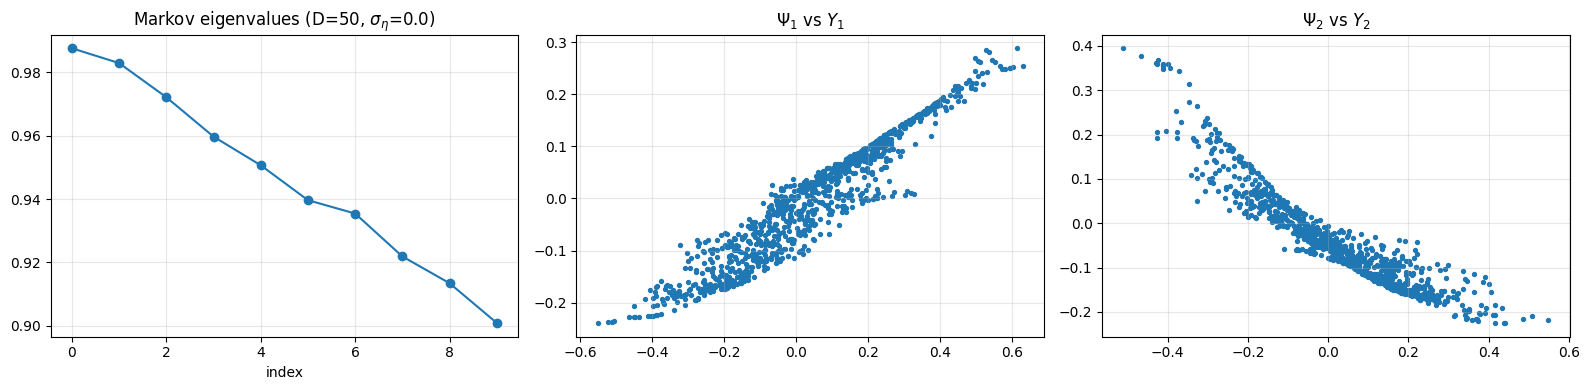

D=50, sigma_eta=0.0: eps*=0.0971  Procrustes disparity=0.0520


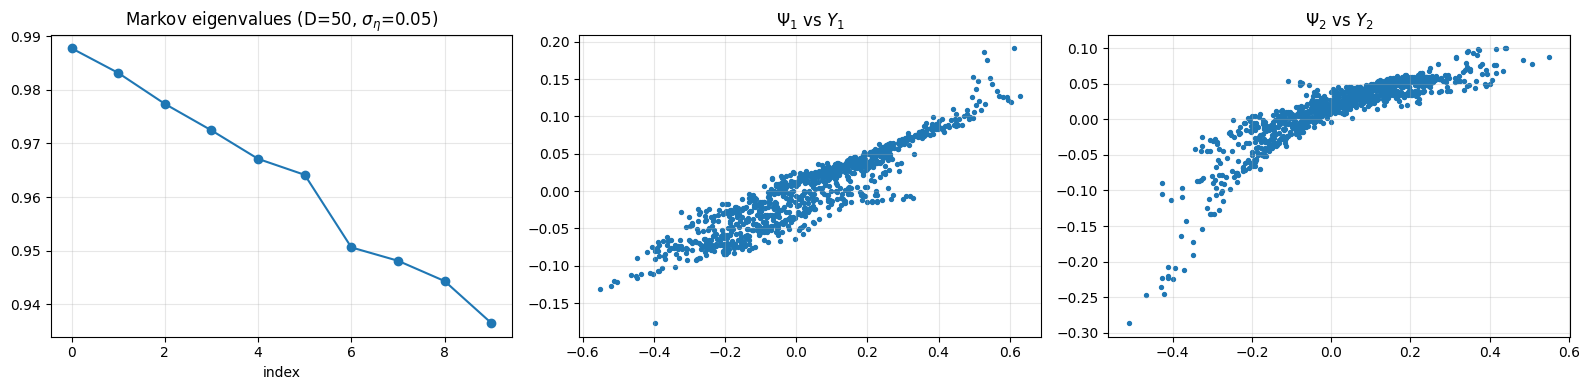

D=50, sigma_eta=0.05: eps*=0.1110  Procrustes disparity=0.1036


In [62]:
def recover_and_plot(D, sigma_eta):
    Z = embed_with_noise(X_geom, W, b, D, eta, sigma_eta)["Zobs"]
    eps, *_ = select_epsilon(Z)                     
    w, Psi = diffusion_map(Z, eps, alpha=1, k=4)
    _, _, disp = procrustes(Y_geom, Psi[:, :2])

    fig, ax = plt.subplots(1, 3, figsize=(16, 4))
    ax[0].plot(w[1:11], 'o-'); ax[0].set_title(f"Markov eigenvalues (D={D}, $\\sigma_\\eta$={sigma_eta})")
    ax[0].set_xlabel("index"); ax[0].grid(alpha=.3)
    ax[1].scatter(Y_geom[:, 0], Psi[:, 0], s=8); ax[1].set_title(r"$\Psi_1$ vs $Y_1$"); ax[1].grid(alpha=.3)
    ax[2].scatter(Y_geom[:, 1], Psi[:, 1], s=8); ax[2].set_title(r"$\Psi_2$ vs $Y_2$"); ax[2].grid(alpha=.3)
    plt.tight_layout(); plt.show()
    print(f"D={D}, sigma_eta={sigma_eta}: eps*={eps:.4f}  Procrustes disparity={disp:.4f}")
    return Psi

Psi_clean = recover_and_plot(50, 0.0)
Psi_noisy = recover_and_plot(50, 0.05)

## 2.4 — Task 3.4: exact-transition MLE of the OU parameters

**Finishing this out** Closed-form exact-transition MLE.

- $\hat a = \big(\sum_i \langle Z_{i+1},Z_i\rangle\big)/\big(\sum_i \|Z_i\|^2\big)$, then
  $\hat\kappa = -\ln\hat a/\Delta t_{\rm eff}$, **uses `dt_eff`**.
- **Identifiability.** $\hat\kappa$ depends only on the lag-1 AR coefficient, which is
  scale-invariant, so it is recoverable directly from $\Psi$. $\hat\sigma$ is confounded with the
  unknown Procrustes scale; report it only when the physical scale of the latent is restored (here we
  validate $\hat\sigma$ against the *true* $Y$, and report only $\hat\kappa$ off $\Psi$).
- **95% CIs via Fisher information** for $\hat a$, propagated to $\kappa$ by the delta method
  $d\kappa/da = -1/(a\,\Delta t_{\rm eff})$.

In [63]:
def ou_mle(Z, dt):
    Z0, Z1 = Z[:-1], Z[1:]
    M = Z0.size                                       
    a = (Z1*Z0).sum()/(Z0*Z0).sum()
    a = min(max(a, 1e-9), 1 - 1e-12)
    kappa = -np.log(a)/dt                             
    resid = Z1 - a*Z0
    s2_innov = (resid**2).sum()/M
    sigma = np.sqrt(s2_innov*2*kappa/(1 - a**2))      
    I_a = (Z0*Z0).sum()/s2_innov                      
    se_kappa = np.sqrt(1.0/I_a)/(a*dt)                
    return kappa, sigma, a, (kappa - 1.96*se_kappa, kappa + 1.96*se_kappa)


k_t, s_t, _, ci_t = ou_mle(Y_geom, dt_eff)
print(f"[truth check]  kappa={k_t:.4f} 95%CI=({ci_t[0]:.3f},{ci_t[1]:.3f})  sigma={s_t:.4f}   (truth 0.5, 0.2)")

for Psi, tag in [(Psi_clean, "D=50, sig=0.00"), (Psi_noisy, "D=50, sig=0.05")]:
    k_h, _, _, ci = ou_mle(Psi[:, :2], dt_eff)
    print(f"[{tag}]  kappa_hat={k_h:.4f} 95%CI=({ci[0]:.3f},{ci[1]:.3f})")

[truth check]  kappa=0.5359 95%CI=(0.385,0.687)  sigma=0.2080   (truth 0.5, 0.2)
[D=50, sig=0.00]  kappa_hat=0.5170 95%CI=(0.369,0.665)
[D=50, sig=0.05]  kappa_hat=0.6430 95%CI=(0.477,0.809)


# Repeating results with Brownian Motion

In [64]:
import numpy as np

def tangent_basis_at(x):
    x = np.asarray(x, dtype=float)
    x = x / np.linalg.norm(x)

    # choose a reference vector not parallel to x
    if abs(x[2]) < 0.9:
        ref = np.array([0.0, 0.0, 1.0])
    else:
        ref = np.array([0.0, 1.0, 0.0])

    e1 = np.cross(ref, x)
    e1 = e1 / np.linalg.norm(e1)

    e2 = np.cross(x, e1)
    e2 = e2 / np.linalg.norm(e2)

    return e1, e2


def exp_sphere(x, v):
    x = np.asarray(x, dtype=float)
    v = np.asarray(v, dtype=float)

    r = np.linalg.norm(v)

    if r < 1e-14:
        return x

    return np.cos(r) * x + np.sin(r) * (v / r)


def simulate_brownian_sphere(
    x0=np.array([0.0, 0.0, 1.0]),
    sigma=1.0,
    dt=0.01,
    T=100.0,
    seed=0
):
    rng = np.random.default_rng(seed)

    N = int(T / dt) + 1
    X = np.zeros((N, 3))

    x = np.asarray(x0, dtype=float)
    x = x / np.linalg.norm(x)

    X[0] = x

    for i in range(1, N):
        e1, e2 = tangent_basis_at(x)

        xi = rng.normal(size=2)
        v = sigma * np.sqrt(dt) * (xi[0] * e1 + xi[1] * e2)

        x = exp_sphere(x, v)
        x = x / np.linalg.norm(x)   # numerical safety

        X[i] = x

    assert np.allclose(np.linalg.norm(X, axis=1), 1.0), "X left S^2"

    return X

In [65]:
X_bm = simulate_brownian_sphere(
    sigma=0.5,
    dt=0.01,
    T=500,
    seed=0
)

In [66]:
burnin = 5000
gap = 20

X_bm_geom = X_bm[burnin::gap]
dt_eff = gap * 0.01

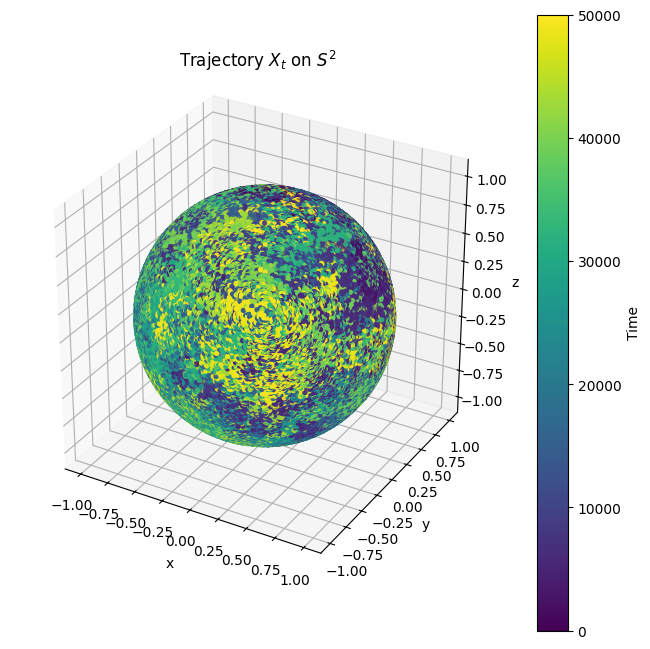

In [67]:
fig = plt.figure(figsize=(8, 8)); ax = fig.add_subplot(111, projection='3d')
u = np.linspace(0, 2*np.pi, 100); v = np.linspace(0, np.pi, 100)
ax.plot_surface(np.outer(np.cos(u), np.sin(v)), np.outer(np.sin(u), np.sin(v)),
                np.outer(np.ones_like(u), np.cos(v)), alpha=0.15, color='lightblue', linewidth=0)
sc = ax.scatter(X_bm[:, 0], X_bm[:, 1], X_bm[:, 2], c=np.arange(len(X_bm)), cmap='viridis', s=8)
fig.colorbar(sc, ax=ax, label='Time'); ax.set_box_aspect([1, 1, 1])
ax.set_xlabel('x'); ax.set_ylabel('y'); ax.set_zlabel('z')
ax.set_title(r'Trajectory $X_t$ on $S^2$'); plt.show()

This basically looks like the uniform points from the sphere in diffusion.ipynb

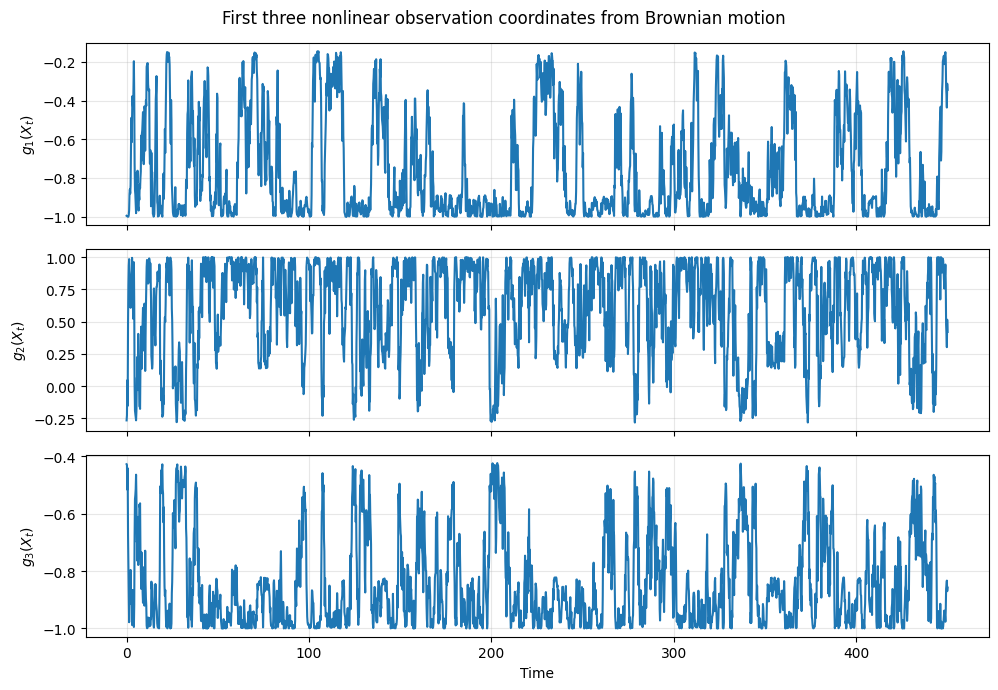

In [68]:
W, b = draw_feature_map(100, FEATURE_SEED)
eta_bm  = np.random.default_rng(NOISE_SEED).standard_normal((X_bm_geom.shape[0], 100))

sigma_etas, Ds = [0.0, 0.05, 0.1, 0.2], [50, 100]

G_bm = embed_with_noise(X_bm_geom, W, b, 50, eta_bm, 0.0)["Gclean"]
t = np.arange(len(G_bm))*dt_eff
fig, axes = plt.subplots(3, 1, figsize=(10, 7), sharex=True)
for j in range(3):
    axes[j].plot(t, G_bm[:, j]); axes[j].set_ylabel(rf"$g_{{{j+1}}}(X_t)$"); axes[j].grid(alpha=.3)
axes[-1].set_xlabel("Time"); fig.suptitle("First three nonlinear observation coordinates from Brownian motion")
plt.tight_layout(); plt.show()

recovered k/2 estimate (max local slope) = 1.189
eps_star (D=50, clean)                   = 6.3480


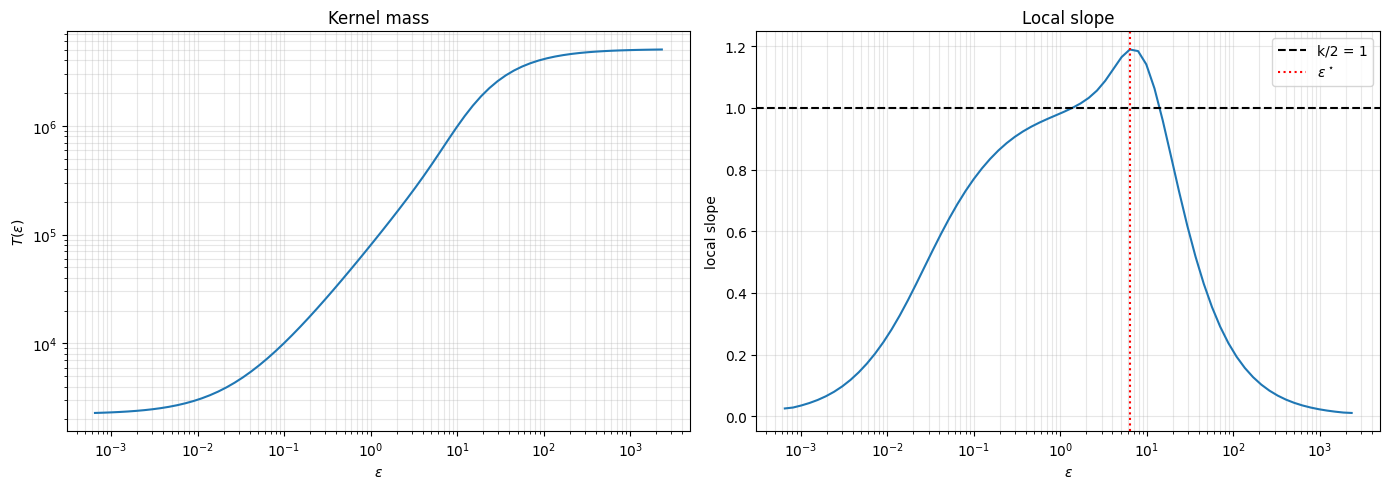

In [69]:

Z0 = embed_with_noise(X_bm_geom, W, b, 50, eta_bm, 0.0)["Zobs"]
eps_star, grid, T, slope = select_epsilon(Z0)
print(f"recovered k/2 estimate (max local slope) = {slope.max():.3f}")
print(f"eps_star (D=50, clean)                   = {eps_star:.4f}")

fig, (a1, a2) = plt.subplots(1, 2, figsize=(14, 5))
a1.loglog(grid, T); a1.set_xlabel(r"$\varepsilon$"); a1.set_ylabel(r"$T(\varepsilon)$")
a1.set_title("Kernel mass"); a1.grid(which='both', alpha=.3)
a2.semilogx(grid, slope); a2.axhline(1, ls='--', c='k', label="k/2 = 1")
a2.axvline(eps_star, ls=':', c='r', label=r"$\varepsilon^\star$")
a2.set_xlabel(r"$\varepsilon$"); a2.set_ylabel("local slope"); a2.set_title("Local slope")
a2.legend(); a2.grid(which='both', alpha=.3); plt.tight_layout(); plt.show()

There seems to be almost a plateau and then the gradient spikes up quickly. This happened for the Swiss roll and the flat torus with uniform sampling. It didn't happen for the uniformly sampled shpere. Could this be due to correlated points? I will chose my range from the first (almost) plateau.

In [70]:
eps_bm = np.sqrt(0.6 * 2.2)
eps_bm

1.1489125293076057

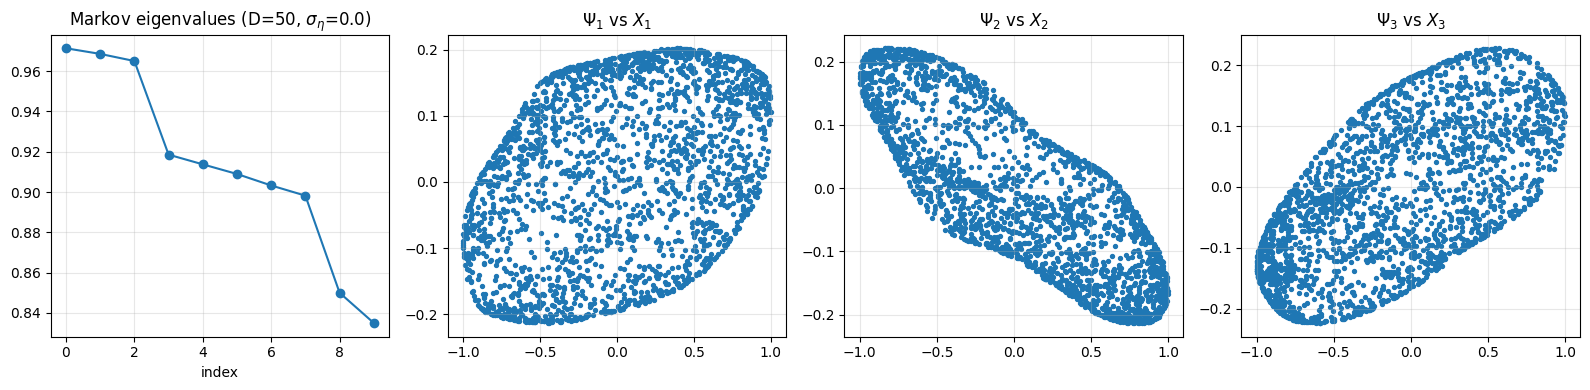

D=50, sigma_eta=0.0: eps*=1.1489  Procrustes disparity=0.0124


In [71]:
def recover_and_plot(D, sigma_eta, eps=None):
    Z = embed_with_noise(X_bm_geom, W, b, D, eta_bm, sigma_eta)["Zobs"]
    if eps is None:
        eps, *_ = select_epsilon(Z)                     
    w, Psi = diffusion_map(Z, eps, alpha=1, k=4)
    _, _, disp = procrustes(X_bm_geom, Psi[:, :3])

    fig, ax = plt.subplots(1, 4, figsize=(16, 4))
    ax[0].plot(w[1:11], 'o-'); ax[0].set_title(f"Markov eigenvalues (D={D}, $\\sigma_\\eta$={sigma_eta})")
    ax[0].set_xlabel("index"); ax[0].grid(alpha=.3)
    ax[1].scatter(X_bm_geom[:, 0], Psi[:, 0], s=8); ax[1].set_title(r"$\Psi_1$ vs $X_1$"); ax[1].grid(alpha=.3)
    ax[2].scatter(X_bm_geom[:, 1], Psi[:, 1], s=8); ax[2].set_title(r"$\Psi_2$ vs $X_2$"); ax[2].grid(alpha=.3)
    ax[3].scatter(X_bm_geom[:, 2], Psi[:, 2], s=8); ax[3].set_title(r"$\Psi_3$ vs $X_3$"); ax[3].grid(alpha=.3)
    plt.tight_layout(); plt.show()
    print(f"D={D}, sigma_eta={sigma_eta}: eps*={eps:.4f}  Procrustes disparity={disp:.4f}")
    return Psi

Psi_clean = recover_and_plot(50, 0.0, eps_bm)

The disparity is tiny in this experiment, I think because the task is not that hard. We only have to recover $X_t$ from $g(X_t)+\eta_t$, rather than finding a $Y_t$. While the disparity is very small, the scatter plots are far more broad than the plots from the OU process on the sphere. Because we are comparing the non-alighned diffusion coordinates and since the full sphere is symmetric, then the leading eigenvectors may not necessarily completly alighn with the orignal coordinates, even though their combination can describe the sphere very well. I will run other metrics to see how well the mapping is recovering the coordinates

In [72]:
def align_embedding(Y, Psi):
    """
    Align diffusion coordinates Psi to latent coordinates Y
    using orthogonal Procrustes alignment.

    Returns:
        Y_c: centred latent coordinates
        Psi_align: centred and aligned embedding
        R: orthogonal transformation
    """

    # centre both clouds
    Y_c = Y - Y.mean(axis=0)
    Psi_c = Psi - Psi.mean(axis=0)
    # best orthogonal map Psi_c @ R ≈ Y_c
    R, _ = orthogonal_procrustes(Psi_c, Y_c)
    # aligned embedding
    Psi_align = Psi_c @ R

    return Y_c, Psi_align, R

def canonical_correlations(A, B, eps=1e-12):
    A = A - A.mean(axis=0)
    B = B - B.mean(axis=0)

    n = A.shape[0]
    Sa = (A.T @ A) / (n - 1)
    Sb = (B.T @ B) / (n - 1)
    Sab = (A.T @ B) / (n - 1)

    eva, Ua = np.linalg.eigh(Sa)
    evb, Ub = np.linalg.eigh(Sb)

    Wa = Ua @ np.diag(1.0 / np.sqrt(np.clip(eva, eps, None))) @ Ua.T
    Wb = Ub @ np.diag(1.0 / np.sqrt(np.clip(evb, eps, None))) @ Ub.T

    return np.linalg.svd(Wa @ Sab @ Wb, compute_uv=False)

def embedding_metrics(target, Psi):
    '''
    Computes all of the required metrics given a target and an embedding

    Returns:
        rmse: RMSE of target and embedding after alignment
        r2: multivariate R^2 value
        cc: the canonical correlations for each dimension of target
        angeles: the principal angles between the recovered and true 2D subspaces
        target_c: centred and normalised target space
        Psi_align: the Psi space centred and aligned optimally to match target
    '''
    # Align embedding using orthogonal Procrustes alignment
    target_c, Psi_align, R = align_embedding(target, Psi)
    scale = np.sum(target_c * Psi_align) / np.sum(Psi_align**2)
    Psi_scaled = scale * Psi_align
    # Find residuals after alignment
    residual = target_c - Psi_scaled
    # Calculate metrics
    rmse = np.sqrt(np.mean(np.sum(residual**2, axis=1)))
    r2 = 1 - np.sum(residual**2) / np.sum(target_c**2)
    angles = subspace_angles(target_c, Psi_align)
    # No need for alignment for this function
    cc = canonical_correlations(target, Psi)
    return rmse, r2, cc, angles, target_c, Psi_align

In [73]:
for sigma in [0.0, 0.05, 0.10, 0.20]:

    Z = embed_with_noise(X_bm_geom, W, b, 50, eta_bm, sigma)["Zobs"]
    w, Psi = diffusion_map(Z, eps_bm, alpha=1, k=3)
    rmse, r2, cc, angles, Y_c, Psi_align = embedding_metrics(X_bm_geom, Psi)
    try: results
    except NameError: results = []
    row = {'sigma': float(sigma), 'D': 50, 'rmse': float(rmse), 'r2': float(r2)}
    for i, val in enumerate(cc, 1):
        row[f'cc{i}'] = float(val)
    for i, ang in enumerate(np.degrees(angles), 1):
        row[f'angle{i}_deg'] = float(ang)

    results.append(row)
    df_results = pd.DataFrame(results)


In [74]:
df_results


,sigma,D,rmse,r2,cc1,cc2,cc3,angle1_deg,angle2_deg,angle3_deg
0,0.00,50,0.110553,0.987570,0.995594,0.994300,0.994011,6.273853,6.120528,5.380670
1,0.05,50,0.112519,0.987124,0.995388,0.994122,0.993681,6.444683,6.215158,5.504725
2,0.10,50,0.118734,0.985663,0.994856,0.993433,0.992555,6.995995,6.570122,5.814127
3,0.20,50,0.173754,0.969296,0.992166,0.985524,0.977814,12.091697,9.760895,7.176326


There seems to be a smooth increase in the RMSE and the angles as the noise increases, so this looks like it is working well.

# OU process on flat torus in $\mathbb{R}^4$

In [75]:
def simulate_ou_on_flat_torus(kappa=0.5, sigma=0.2,
                          dt=0.01, T=100, d=2, rand_seed=0):
    rng = np.random.default_rng(rand_seed)                      
    N = int(T/dt) + 1
    Y = np.zeros((N, d))
    stat_sd = sigma/np.sqrt(2*kappa)
    Y[0] = rng.normal(0.0, stat_sd, size=d)                     
    a      = np.exp(-kappa*dt)                                  
    ou_std = np.sqrt(sigma**2/(2*kappa)*(1 - np.exp(-2*kappa*dt)))  
    for t in range(1, N):
        Y[t] = a*Y[t-1] + ou_std*rng.normal(0.0, 1.0, size=d)
    theta0, phi0 = 0.0, 0.0
    theta = theta0 + Y[:, 0]; phi = phi0 + Y[:, 1]
    X = np.stack((np.cos(theta), np.sin(theta), np.cos(phi), np.sin(phi)), axis=1)
    return X, Y

X_ft, Y_ft = simulate_ou_on_flat_torus(rand_seed=LATENT_SEED)

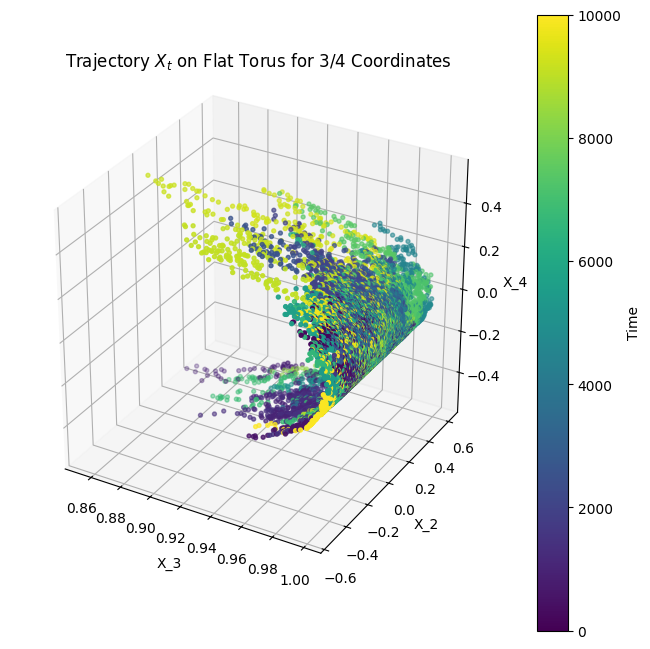

In [76]:
fig = plt.figure(figsize=(8, 8)); ax = fig.add_subplot(111, projection='3d')
u = np.linspace(0, 2*np.pi, 100); v = np.linspace(0, np.pi, 100)
sc = ax.scatter(X_ft[:, 2], X_ft[:, 1], X_ft[:, 3], c=np.arange(len(X_ft)), cmap='viridis', s=8)
fig.colorbar(sc, ax=ax, label='Time'); ax.set_box_aspect([1, 1, 1])
ax.set_xlabel('X_3'); ax.set_ylabel('X_2'); ax.set_zlabel('X_4')
ax.set_title(r'Trajectory $X_t$ on Flat Torus for 3/4 Coordinates'); plt.show()

In [77]:
burnin, gap = 500, 10
dt = 0.01
dt_eff = gap*dt                                   

X_ft_geom, Y_ft_geom = X_ft[burnin::gap], Y_ft[burnin::gap]   
print("n_geom =", X_ft_geom.shape[0], " dt_eff =", dt_eff)

n_geom = 951  dt_eff = 0.1


### Plotting clean $g(X_t)$ for OU on flat torus

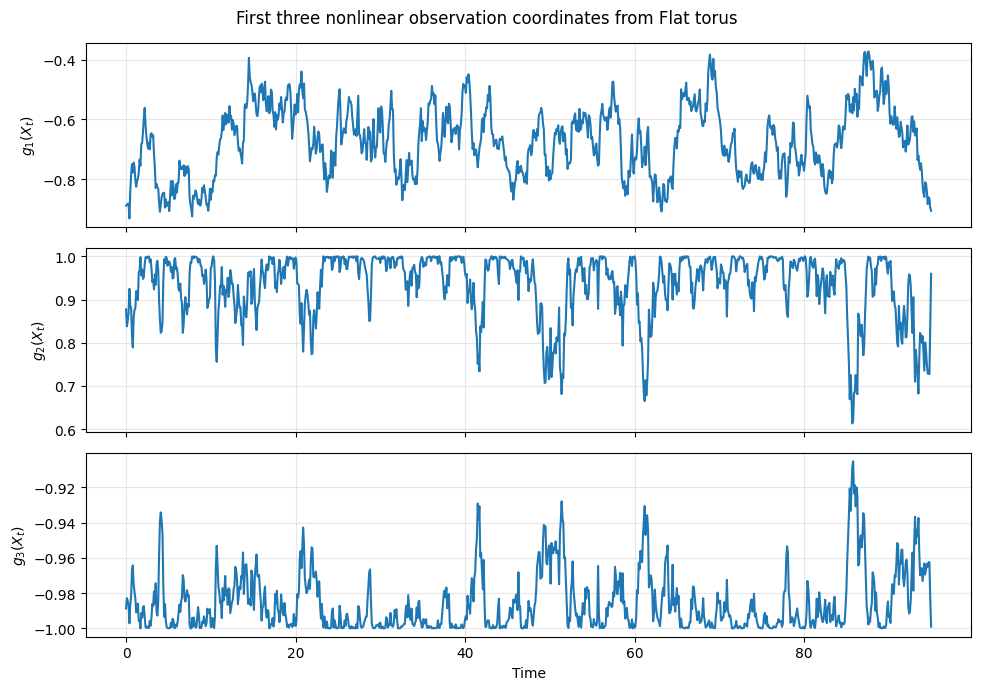

In [78]:
W_ft, b = draw_feature_map(100, FEATURE_SEED, d=4)
eta  = np.random.default_rng(NOISE_SEED).standard_normal((X_ft_geom.shape[0], 100))

sigma_etas, Ds = [0.0, 0.05, 0.1, 0.2], [50, 100]

G_ft = embed_with_noise(X_ft_geom, W_ft, b, 50, eta, 0.0)["Gclean"]
t = np.arange(len(G))*dt_eff
fig, axes = plt.subplots(3, 1, figsize=(10, 7), sharex=True)
for j in range(3):
    axes[j].plot(t, G[:, j]); axes[j].set_ylabel(rf"$g_{{{j+1}}}(X_t)$"); axes[j].grid(alpha=.3)
axes[-1].set_xlabel("Time"); fig.suptitle("First three nonlinear observation coordinates from Flat torus")
plt.tight_layout(); plt.show()

### Kernel mass plot to find $\varepsilon^\star$ for flat torus

recovered k/2 estimate (max local slope) = 0.936
eps_star (D=50, clean)                   = 0.1059


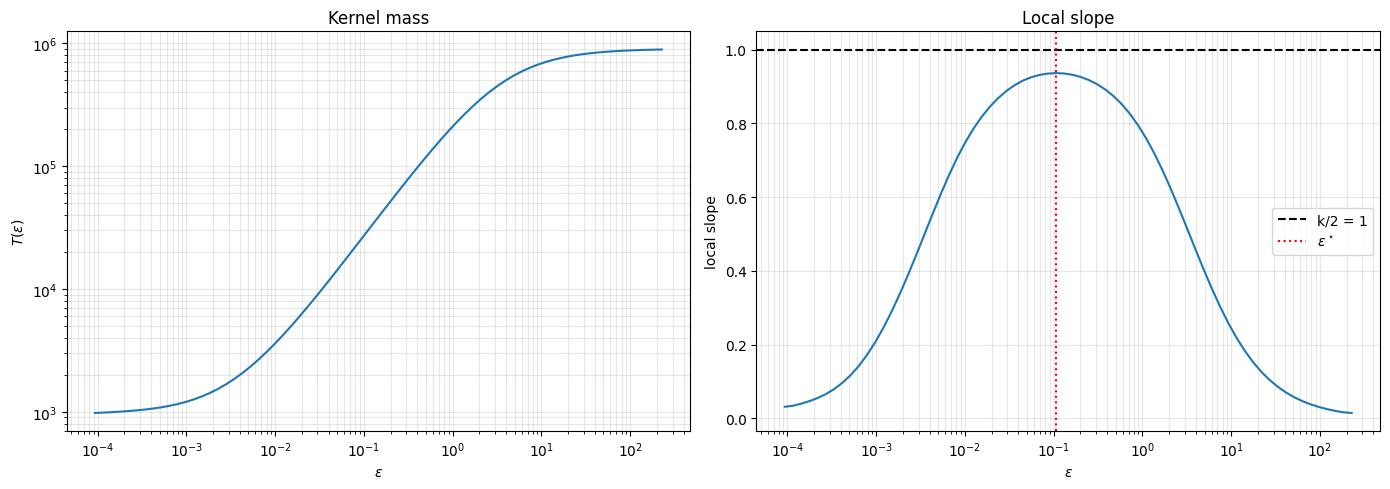

In [79]:
Z0_ft = embed_with_noise(X_ft_geom, W_ft, b, 50, eta, 0.0)["Zobs"]
eps_star, grid, T, slope = select_epsilon(Z0_ft)
print(f"recovered k/2 estimate (max local slope) = {slope.max():.3f}")
print(f"eps_star (D=50, clean)                   = {eps_star:.4f}")

fig, (a1, a2) = plt.subplots(1, 2, figsize=(14, 5))
a1.loglog(grid, T); a1.set_xlabel(r"$\varepsilon$"); a1.set_ylabel(r"$T(\varepsilon)$")
a1.set_title("Kernel mass"); a1.grid(which='both', alpha=.3)
a2.semilogx(grid, slope); a2.axhline(1, ls='--', c='k', label="k/2 = 1")
a2.axvline(eps_star, ls=':', c='r', label=r"$\varepsilon^\star$")
a2.set_xlabel(r"$\varepsilon$"); a2.set_ylabel("local slope"); a2.set_title("Local slope")
a2.legend(); a2.grid(which='both', alpha=.3); plt.tight_layout(); plt.show()

I am happy with this plot, it looks as expected

### Plotting eigenvalues and diffusion coordinates against latent coordinates for flat torus

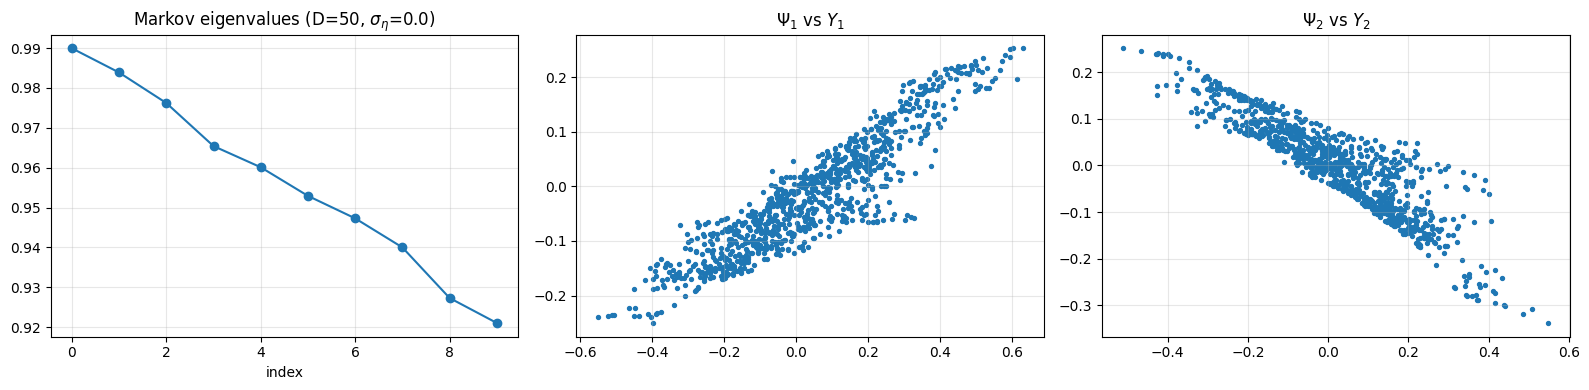

D=50, sigma_eta=0.0: eps*=0.1059  Procrustes disparity=0.0388


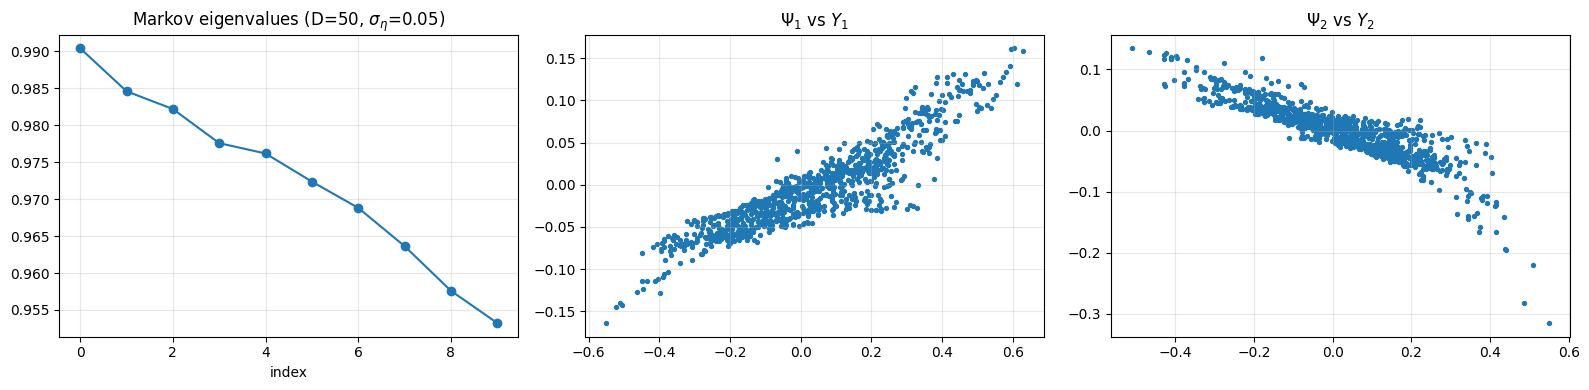

D=50, sigma_eta=0.05: eps*=0.1140  Procrustes disparity=0.0630


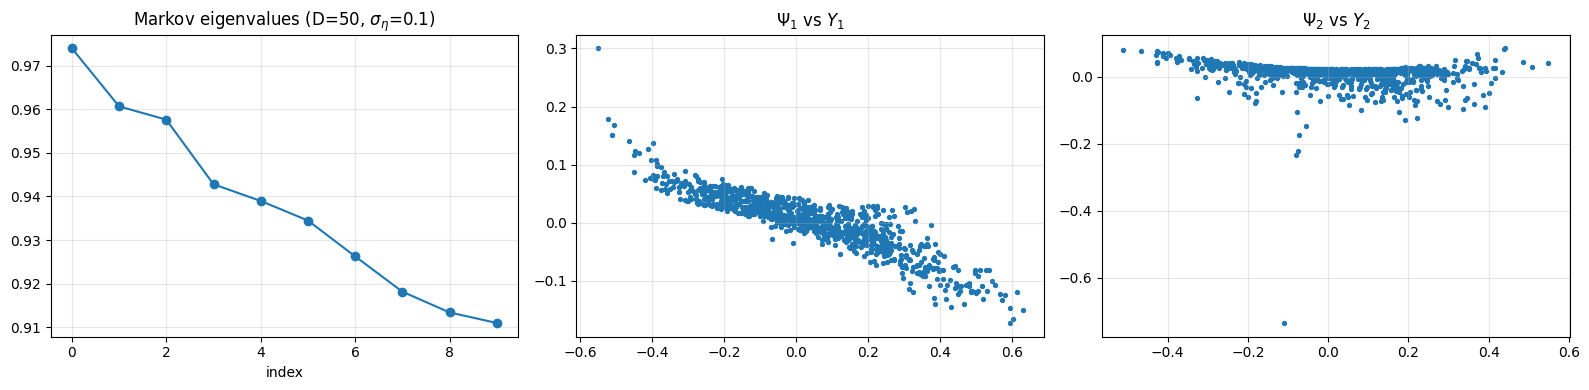

D=50, sigma_eta=0.1: eps*=0.3089  Procrustes disparity=0.5991


In [80]:
def recover_and_plot(X, W, b, D, sigma_eta):
    Z = embed_with_noise(X, W, b, D, eta, sigma_eta)["Zobs"]
    eps, *_ = select_epsilon(Z)                     
    w, Psi = diffusion_map(Z, eps, alpha=1, k=4)
    _, _, disp = procrustes(Y_geom, Psi[:, :2])

    fig, ax = plt.subplots(1, 3, figsize=(16, 4))
    ax[0].plot(w[1:11], 'o-'); ax[0].set_title(f"Markov eigenvalues (D={D}, $\\sigma_\\eta$={sigma_eta})")
    ax[0].set_xlabel("index"); ax[0].grid(alpha=.3)
    ax[1].scatter(Y_geom[:, 0], Psi[:, 0], s=8); ax[1].set_title(r"$\Psi_1$ vs $Y_1$"); ax[1].grid(alpha=.3)
    ax[2].scatter(Y_geom[:, 1], Psi[:, 1], s=8); ax[2].set_title(r"$\Psi_2$ vs $Y_2$"); ax[2].grid(alpha=.3)
    plt.tight_layout(); plt.show()
    print(f"D={D}, sigma_eta={sigma_eta}: eps*={eps:.4f}  Procrustes disparity={disp:.4f}")
    return Psi

Psi_clean = recover_and_plot(X_ft_geom, W_ft, b, 50, 0.00)
Psi_noisy = recover_and_plot(X_ft_geom, W_ft, b, 50, 0.05)
Psi_more_noisy= recover_and_plot(X_ft_geom, W_ft, b, 50, 0.10)

The disparity gradually increasing with noise is expected

### OU MLE from flat torus diffusion-map embedding

In [81]:
k_t, s_t, _, ci_t = ou_mle(Y_ft_geom, dt_eff)
print(f"[truth check]  kappa={k_t:.4f} 95%CI=({ci_t[0]:.3f},{ci_t[1]:.3f})  sigma={s_t:.4f}   (truth 0.5, 0.2)")

for Psi, tag in [(Psi_clean, "D=50, sig=0.00"), (Psi_noisy, "D=50, sig=0.05"), (Psi_more_noisy, "D=50, sig=0.10")]:
    k_h, _, _, ci = ou_mle(Psi[:, :2], dt_eff)
    print(f"[{tag}]  kappa_hat={k_h:.4f} 95%CI=({ci[0]:.3f},{ci[1]:.3f})")

[truth check]  kappa=0.5359 95%CI=(0.385,0.687)  sigma=0.2080   (truth 0.5, 0.2)
[D=50, sig=0.00]  kappa_hat=0.5500 95%CI=(0.397,0.703)
[D=50, sig=0.05]  kappa_hat=0.6548 95%CI=(0.487,0.822)
[D=50, sig=0.10]  kappa_hat=1.7887 95%CI=(1.495,2.083)


For $\sigma_\eta \in \{0.00, 0.05\}$, we find an acceptable value for $\hat\kappa$, but for $\sigma_\eta = 0.10$ we do not. This lines up with the disparity being ~0.5 for this level of noise; the latent coordinates are not well recovered.